# Laboratuvar Temel Modeli
## Heart Failure Clinical Records Veri Seti ile Manuel Neural Network

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
X = df.drop("DEATH_EVENT", axis=1).values
y = df["DEATH_EVENT"].values.reshape(1, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y.T, test_size=0.30, random_state=42, stratify=y.T
)

# Manuel model için transpose ediyoruz
X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12, 209)
X_test shape: (12, 90)
y_train shape: (1, 209)
y_test shape: (1, 90)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.T).T
X_test_scaled = scaler.transform(X_test.T).T

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (12, 209)
X_test_scaled shape: (12, 90)


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(42)
    
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    
    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }
    
    return parameters

In [13]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }
    
    return A2, cache

In [14]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    epsilon = 1e-8
    
    cost = - (1 / m) * np.sum(
        Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon)
    )
    
    return np.squeeze(cost)

In [15]:
def backpropagation(parameters, cache, X, Y):
    m = X.shape[1]
    
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }
    
    return grads

In [16]:
def update_parameters(parameters, grads, learning_rate=0.01):
    parameters["W1"] = parameters["W1"] - learning_rate * grads["dW1"]
    parameters["b1"] = parameters["b1"] - learning_rate * grads["db1"]
    parameters["W2"] = parameters["W2"] - learning_rate * grads["dW2"]
    parameters["b2"] = parameters["b2"] - learning_rate * grads["db2"]
    
    return parameters

In [17]:
def nn_model(X, Y, n_h, num_iterations=1000, learning_rate=0.01):
    np.random.seed(42)
    
    n_x = X.shape[0]
    n_y = Y.shape[0]
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    costs = []
    
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        
        cost = compute_cost(A2, Y)
        
        grads = backpropagation(parameters, cache, X, Y)
        
        parameters = update_parameters(parameters, grads, learning_rate)
        
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

In [18]:
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    predictions = (A2 > 0.5).astype(int)
    return predictions

In [19]:
parameters, costs = nn_model(
    X_train_scaled,
    y_train,
    n_h=8,
    num_iterations=1000,
    learning_rate=0.01
)

print("Eğitim tamam")

Eğitim tamam


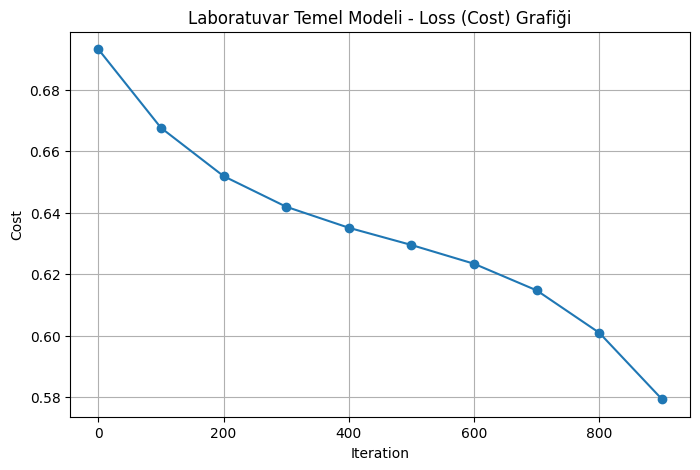

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(0, len(costs) * 100, 100), costs, marker='o')
plt.title("Laboratuvar Temel Modeli - Loss (Cost) Grafiği")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

### Loss Grafiği Yorumu

Loss (cost) grafiği, laboratuvar temel modelinin eğitim sürecinde hata değerinin genel olarak azaldığını göstermektedir. Bu durum modelin eğitim verisi üzerinde belirli düzeyde öğrenme gerçekleştirdiğini göstermektedir.

Bununla birlikte, test sonuçlarında görüldüğü üzere model özellikle pozitif sınıfı (`DEATH_EVENT = 1`) tahmin etmede yetersiz kalmıştır. Bu nedenle yalnızca loss değerindeki azalma, modelin genelleme performansının yeterli olduğu anlamına gelmemektedir.

Bu gözlem, daha gelişmiş mimariler ve kütüphane tabanlı modeller ile karşılaştırmalı değerlendirme yapılmasının gerekli olduğunu göstermektedir.

In [20]:
y_train_pred_lab = predict(X_train_scaled, parameters)
y_test_pred_lab = predict(X_test_scaled, parameters)

train_acc_lab = accuracy_score(y_train.flatten(), y_train_pred_lab.flatten())
test_acc_lab = accuracy_score(y_test.flatten(), y_test_pred_lab.flatten())

print("Train Accuracy (Lab Model):", train_acc_lab)
print("Test Accuracy (Lab Model):", test_acc_lab)

Train Accuracy (Lab Model): 0.69377990430622
Test Accuracy (Lab Model): 0.6777777777777778


In [21]:
print("Classification Report (Lab Model):")
print(classification_report(y_test.flatten(), y_test_pred_lab.flatten()))

print("Confusion Matrix (Lab Model):")
print(confusion_matrix(y_test.flatten(), y_test_pred_lab.flatten()))

Classification Report (Lab Model):
              precision    recall  f1-score   support

           0       0.68      1.00      0.81        61
           1       0.00      0.00      0.00        29

    accuracy                           0.68        90
   macro avg       0.34      0.50      0.40        90
weighted avg       0.46      0.68      0.55        90

Confusion Matrix (Lab Model):
[[61  0]
 [29  0]]


c:\Users\ENES\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ENES\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag